In [1]:
import random
import numpy as np
import os

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_seed(42)


In [2]:
# ============================================================
# 1. Imports
# ============================================================
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from collections import Counter
device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# 2. Load IMDB CSV
# ============================================================
df = pd.read_csv("input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df['sentiment'] = df['sentiment'].map({"positive":1, "negative":0})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [3]:
# ============================================================
# 3. Preprocessing + Tokenizer
# ============================================================
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-zA-Z0-9\s]", "", t)
    return t

df["review"] = df["review"].apply(clean_text)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production br br the filmin...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [4]:


# Build vocab
all_words = " ".join(df["review"].tolist()).split()
vocab_count = Counter(all_words)
vocab = {w:i+4 for i,(w,c) in enumerate(vocab_count.items())}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
vocab["<START>"] = 2
vocab["<END>"] = 3

vocab_size = len(vocab)

def encode(text):
    tokens = text.split()
    ids = [2]  # <START>
    for t in tokens:
        ids.append(vocab.get(t, 1))   # <UNK>
    ids.append(3)  # <END>
    return ids

df["encoded"] = df["review"].apply(encode)
df.head()

,review,sentiment,encoded
0,one of the other reviewers has mentioned that ...,1,"[2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ..."
1,a wonderful little production br br the filmin...,1,"[2, 53, 195, 196, 197, 32, 32, 6, 198, 199, 26..."
2,i thought this was a wonderful way to spend ti...,1,"[2, 121, 275, 25, 38, 53, 195, 276, 64, 277, 2..."
3,basically theres a family where a little boy j...,0,"[2, 353, 354, 53, 355, 89, 53, 196, 356, 357, ..."
4,petter matteis love in the time of money is a ...,1,"[2, 403, 404, 405, 47, 6, 278, 5, 406, 26, 53,..."


In [5]:
sample_items = list(vocab.items())[:6]
print(sample_items)


[('one', 4), ('of', 5), ('the', 6), ('other', 7), ('reviewers', 8), ('has', 9)]


In [6]:
# ============================================================
# 4. Dataset Class
# ============================================================
class IMDBDataset(Dataset):
    def __init__(self, X, y, maxlen):
        self.X = X
        self.y = y
        self.maxlen = maxlen

    def pad(self, seq):
        if len(seq) >= self.maxlen:
            return seq[:self.maxlen]
        return seq + [0]*(self.maxlen - len(seq))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.pad(self.X[idx])), torch.tensor(self.y[idx])

# ============================================================
# 5. Simple RNN / LSTM Models
# ============================================================
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        e = self.emb(x)
        out, h = self.rnn(e)
        return torch.sigmoid(self.fc(h[-1]))

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        e = self.emb(x)
        out, (h, c) = self.lstm(e)
        return torch.sigmoid(self.fc(h[-1]))

# ============================================================
# 6. Train loop
# ============================================================
def train_model(model, train_loader, val_loader, epochs=20):
    model = model.to(device)
    criterion = nn.BCELoss()
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = []

    for epoch in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.float().to(device)
            pred = model(X).squeeze()
            loss = criterion(pred, y)

            optim.zero_grad()
            loss.backward()
            optim.step()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.float().to(device)
                pred = model(X).squeeze()
                p = (pred >= 0.5).float()
                correct += (p == y).sum().item()
                total += y.size(0)

        acc = correct/total
        history.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | Val Acc: {acc:.4f}")

    return history

# ============================================================
# 7. Final Pipeline
# ============================================================
SEQ_LENS = [50, 100, 200, 400]

results = {}

train_X, val_X, train_y, val_y = train_test_split(
    df["encoded"], df["sentiment"], test_size=0.2, random_state=42)

for L in SEQ_LENS:
    print("\n======================================")
    print(f"Training with sequence length: {L}")
    print("======================================")

    train_ds = IMDBDataset(train_X.tolist(), train_y.tolist(), maxlen=L)
    val_ds   = IMDBDataset(val_X.tolist(), val_y.tolist(), maxlen=L)

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=128)

    print("\n--- RNN ---")
    rnn = RNNClassifier(vocab_size)
    rnn_acc = train_model(rnn, train_loader, val_loader)

    print("\n--- LSTM ---")
    lstm = LSTMClassifier(vocab_size)
    lstm_acc = train_model(lstm, train_loader, val_loader)

    results[L] = {
        "rnn_acc": rnn_acc,
        "lstm_acc": lstm_acc,
        "rnn": rnn,
        "lstm": lstm
    }

# ============================================================
# Print final results
# ============================================================
print("\n\n===== FINAL RESULTS =====")
for L in results:
    print(f"\nSeq Length = {L}")
    print("RNN  Acc:", results[L]["rnn_acc"][-1])
    print("LSTM Acc:", results[L]["lstm_acc"][-1])



Training with sequence length: 50

--- RNN ---
Epoch 1/20 | Val Acc: 0.6500
Epoch 2/20 | Val Acc: 0.6000
Epoch 3/20 | Val Acc: 0.4500
Epoch 4/20 | Val Acc: 0.5000
Epoch 5/20 | Val Acc: 0.4000
Epoch 6/20 | Val Acc: 0.4000
Epoch 7/20 | Val Acc: 0.4000
Epoch 8/20 | Val Acc: 0.3500
Epoch 9/20 | Val Acc: 0.3500
Epoch 10/20 | Val Acc: 0.3500
Epoch 11/20 | Val Acc: 0.3500
Epoch 12/20 | Val Acc: 0.3500
Epoch 13/20 | Val Acc: 0.3500
Epoch 14/20 | Val Acc: 0.3500
Epoch 15/20 | Val Acc: 0.3500
Epoch 16/20 | Val Acc: 0.3500
Epoch 17/20 | Val Acc: 0.3500
Epoch 18/20 | Val Acc: 0.3500
Epoch 19/20 | Val Acc: 0.3500
Epoch 20/20 | Val Acc: 0.3500

--- LSTM ---
Epoch 1/20 | Val Acc: 0.6000
Epoch 2/20 | Val Acc: 0.5500
Epoch 3/20 | Val Acc: 0.5500
Epoch 4/20 | Val Acc: 0.5000
Epoch 5/20 | Val Acc: 0.4500
Epoch 6/20 | Val Acc: 0.4500
Epoch 7/20 | Val Acc: 0.4500
Epoch 8/20 | Val Acc: 0.4500
Epoch 9/20 | Val Acc: 0.4000
Epoch 10/20 | Val Acc: 0.4000
Epoch 11/20 | Val Acc: 0.4000
Epoch 12/20 | Val Acc: 0.4

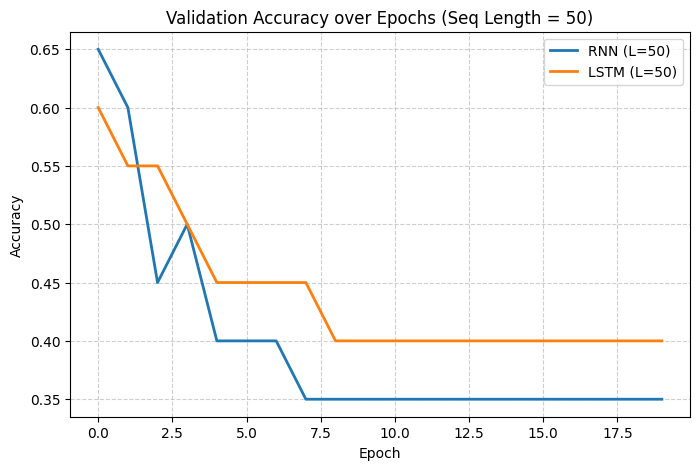

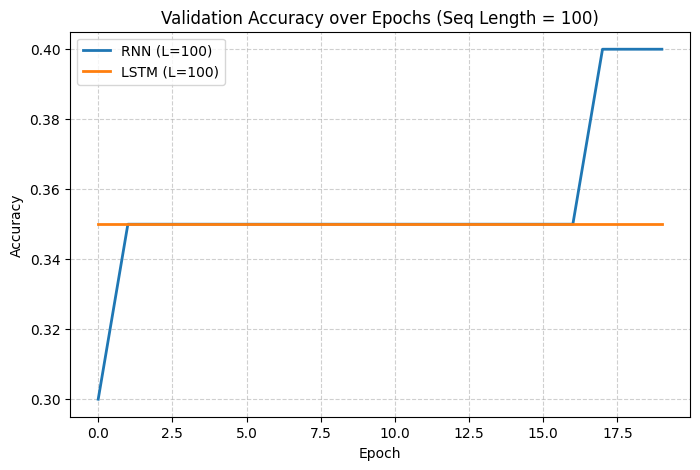

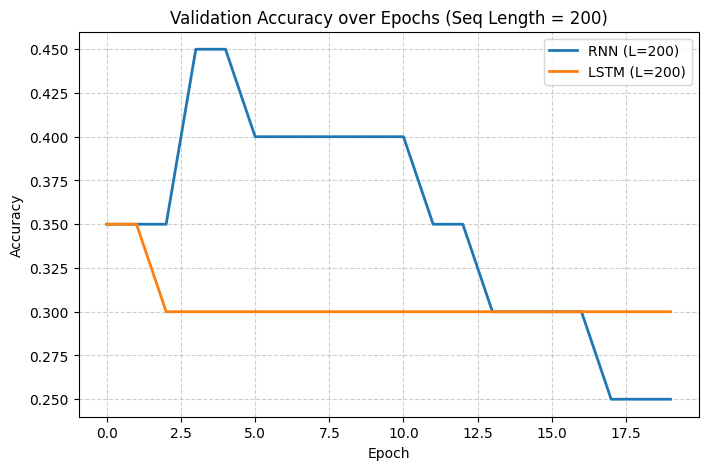

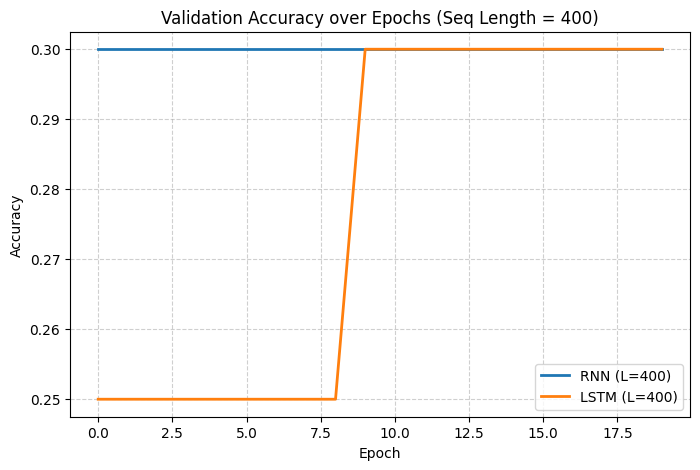

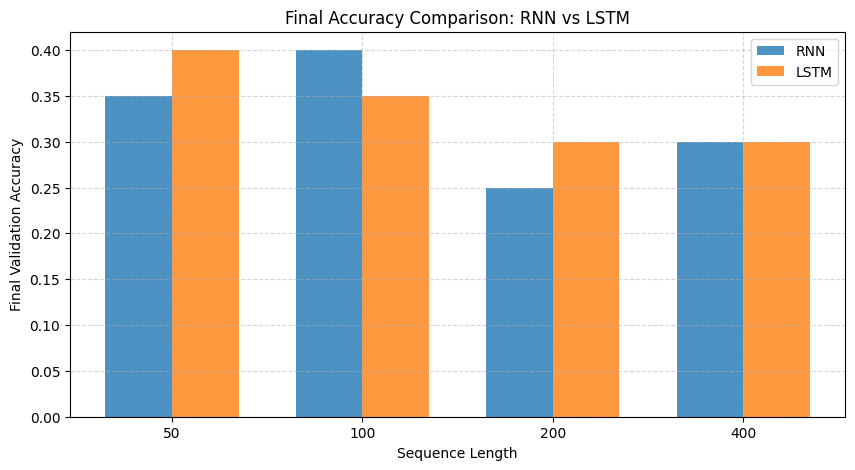

In [7]:
import matplotlib.pyplot as plt

# ============================================================
# 1. Plot accuracy curves for each sequence length
# ============================================================
for L in results:
    rnn_acc = results[L]["rnn_acc"]
    lstm_acc = results[L]["lstm_acc"]

    plt.figure(figsize=(8,5))
    plt.plot(rnn_acc, label=f"RNN (L={L})", linewidth=2)
    plt.plot(lstm_acc, label=f"LSTM (L={L})", linewidth=2)
    plt.title(f"Validation Accuracy over Epochs (Seq Length = {L})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

# ============================================================
# 2. Bar plot
# ============================================================
final_rnn = []
final_lstm = []

for L in SEQ_LENS:
    final_rnn.append(results[L]["rnn_acc"][-1])
    final_lstm.append(results[L]["lstm_acc"][-1])

x = np.arange(len(SEQ_LENS))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, final_rnn, width, label="RNN", alpha=0.8)
plt.bar(x + width/2, final_lstm, width, label="LSTM", alpha=0.8)

plt.xticks(x, SEQ_LENS)
plt.xlabel("Sequence Length")
plt.ylabel("Final Validation Accuracy")
plt.title("Final Accuracy Comparison: RNN vs LSTM")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [10]:
best_rnn_idx = np.argmax(final_rnn)
best_lstm_idx = np.argmax(final_lstm)
os.makedirs("output", exist_ok=True)
if final_rnn[best_rnn_idx] > final_lstm[best_lstm_idx]:
    torch.save(results[50*2**best_rnn_idx]["rnn"], "output/model.pt")
else:
    torch.save(results[50*2**best_lstm_idx]["lstm"], "output/model.pt")